Successfully loaded 'samples_cancer.csv'

Dataset head:
        ID  Clump  UnifSize  UnifShape  MargAdh  SingEpiSize BareNuc  \
0  1000025      5         1          1        1            2       1   
1  1002945      5         4          4        5            7      10   
2  1015425      3         1          1        1            2       2   
3  1016277      6         8          8        1            3       4   
4  1017023      4         1          1        3            2       1   

   BlandChrom  NormNucl  Mit  Class  
0           3         1    1      2  
1           3         2    1      2  
2           3         1    1      2  
3           3         7    1      2  
4           3         1    1      2  

Target column 'Class' is not 0/1. Original values: [2 4]
Transformed target to: [0 1] (mapped from [2 4])

Successfully trained Logistic Regression model.

--- Model Evaluation Metrics ---
Accuracy:   0.9500
Precision:  0.9362
Recall:     0.9167
F1-Score:   0.9263
AUC Score:  0.995

/tmp/ipython-input-4294299661.py:60: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[column].fillna(median_val, inplace=True)



Saved plot: 'confusion_matrix.png'
True Negatives (Benign): 89
False Positives (Benign): 3
False Negatives (Malignant): 4
True Positives (Malignant): 44
Saved plot: 'roc_curve.png'


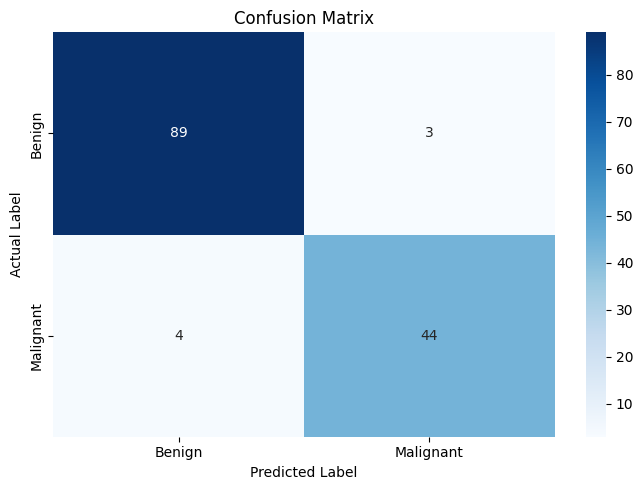

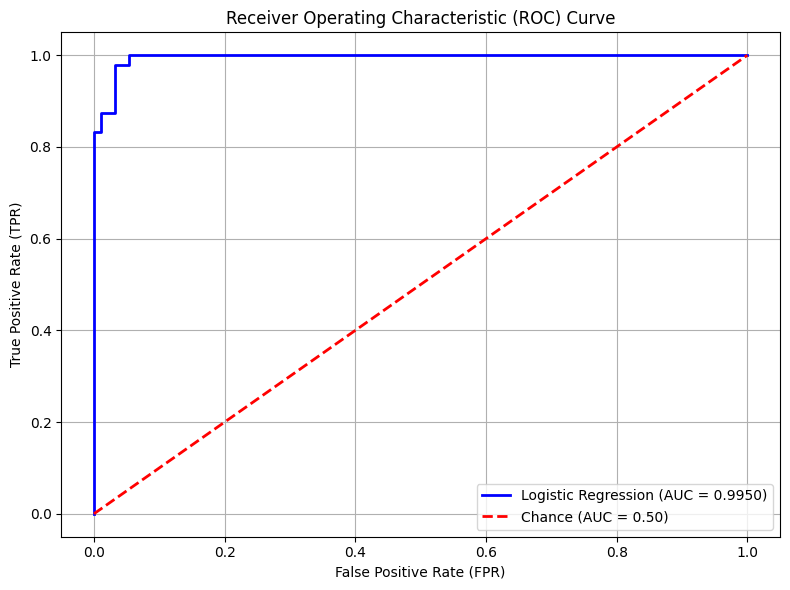

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_curve,
    roc_auc_score
)

try:
    df = pd.read_csv('samples_cancer.csv')
    print("Successfully loaded 'samples_cancer.csv'")
except FileNotFoundError:
    print("Warning: 'samples_cancer.csv' not found. Creating a sample dataset.")
    np.random.seed(42)
    num_samples = 200
    X_benign = np.random.normal(loc=3, scale=1.5, size=(num_samples//2, 5))
    X_malignant = np.random.normal(loc=6, scale=1.5, size=(num_samples//2, 5))

    X_data = np.vstack([X_benign, X_malignant])
    y_data = np.array([0] * (num_samples//2) + [1] * (num_samples//2))

    indices = np.arange(num_samples)
    np.random.shuffle(indices)
    X_data = X_data[indices]
    y_data = y_data[indices]

    df = pd.DataFrame(X_data, columns=['Feature_1', 'Feature_2', 'Feature_3', 'Feature_4', 'Feature_5'])
    df['Class'] = y_data

print("\nDataset head:")
print(df.head())

if 'Class' not in df.columns:
    print("\nError: Target column 'Class' not found. Aborting.")
else:
    for column in df.columns:
        if df[column].dtype == 'object':
            df[column] = df[column].replace('?', np.nan)
            try:
                df[column] = pd.to_numeric(df[column])
            except ValueError:
                pass

    for column in df.columns:
        if df[column].dtype in ['int64', 'float64'] and df[column].isnull().any():
            median_val = df[column].median()
            df[column].fillna(median_val, inplace=True)

    X = df.drop(['Class', 'ID', 'Unnamed: 32'], axis=1, errors='ignore')
    y = df['Class']

    if y.dtype == 'object' or len(np.unique(y)) > 2 or y.min() != 0:
        print(f"\nTarget column 'Class' is not 0/1. Original values: {np.unique(y)}")
        le = LabelEncoder()
        y = le.fit_transform(y)
        class_names = ['Benign', 'Malignant']
        print(f"Transformed target to: {np.unique(y)} (mapped from {le.classes_})")
    else:
        class_names = ['Benign (0)', 'Malignant (1)']
        print("\nTarget column 'Class' is already in 0/1 format.")

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )

    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    model = LogisticRegression(random_state=42)
    model.fit(X_train_scaled, y_train)
    print("\nSuccessfully trained Logistic Regression model.")

    y_pred = model.predict(X_test_scaled)
    y_pred_proba = model.predict_proba(X_test_scaled)[:, 1]

    print("\n--- Model Evaluation Metrics ---")

    accuracy = accuracy_score(y_test, y_pred)
    print(f"Accuracy:   {accuracy:.4f}")

    precision = precision_score(y_test, y_pred)
    print(f"Precision:  {precision:.4f}")

    recall = recall_score(y_test, y_pred)
    print(f"Recall:     {recall:.4f}")

    f1 = f1_score(y_test, y_pred)
    print(f"F1-Score:   {f1:.4f}")

    auc_score = roc_auc_score(y_test, y_pred_proba)
    print(f"AUC Score:  {auc_score:.4f}")

    print("\n--- Classification Report ---")
    print(classification_report(y_test, y_pred, target_names=class_names))

    print("--- Confusion Matrix ---")
    cm = confusion_matrix(y_test, y_pred)

    plt.figure(figsize=(7, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names,
                yticklabels=class_names)
    plt.title('Confusion Matrix')
    plt.ylabel('Actual Label')
    plt.xlabel('Predicted Label')
    plt.tight_layout()
    plt.savefig('confusion_matrix.png')
    print("\nSaved plot: 'confusion_matrix.png'")
    print(f"True Negatives (Benign): {cm[0, 0]}")
    print(f"False Positives (Benign): {cm[0, 1]}")
    print(f"False Negatives (Malignant): {cm[1, 0]}")
    print(f"True Positives (Malignant): {cm[1, 1]}")

    fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)

    plt.figure(figsize=(8, 6))
    plt.plot(fpr, tpr, color='blue', lw=2, label=f'Logistic Regression (AUC = {auc_score:.4f})')
    plt.plot([0, 1], [0, 1], color='red', lw=2, linestyle='--', label='Chance (AUC = 0.50)')
    plt.xlabel('False Positive Rate (FPR)')
    plt.ylabel('True Positive Rate (TPR)')
    plt.title('Receiver Operating Characteristic (ROC) Curve')
    plt.legend(loc='lower right')
    plt.grid(True)
    plt.tight_layout()
    plt.savefig('roc_curve.png')
    print("Saved plot: 'roc_curve.png'")